# Basics of time series forecasting

This lab introduces the fundamentals of time series forecasting with deep learning.
You will learn how to build data loaders for time series data, implement simple
autoregressive models, and experiment with preprocessing techniques such as
standardization and differencing. The lab covers training and evaluation procedures,
and compares the impact of different modeling choices on forecasting performance.

In [ ]:
import torch
import numpy
import matplotlib.pyplot as plt

## Part 1: Data loaders

In this section, you will load a standard time series forecasting dataset and prepare a data loader for it.

To begin, visit <https://github.com/zhouhaoyi/ETDataset> and download the ETTh1 dataset as a CSV file.

**Question 1.** Visualize the dataset, focusing on the univariate time series corresponding to the target variable. Do you observe a trend? Periodicity? Any abnormal segments?

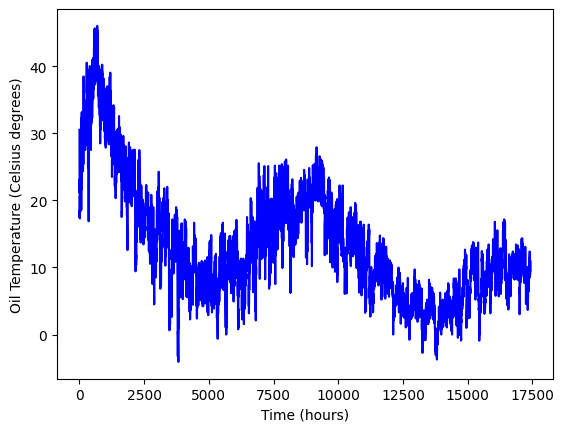

In [4]:
raw = numpy.loadtxt("/content/ETTh1.csv", delimiter=",", skiprows=1, usecols=-1)
series = raw.astype(numpy.float32)
plt.plot(series, color='blue')
plt.xlabel("Time (hours)")
plt.ylabel("Oil Temperature (Celsius degrees)")
plt.show()

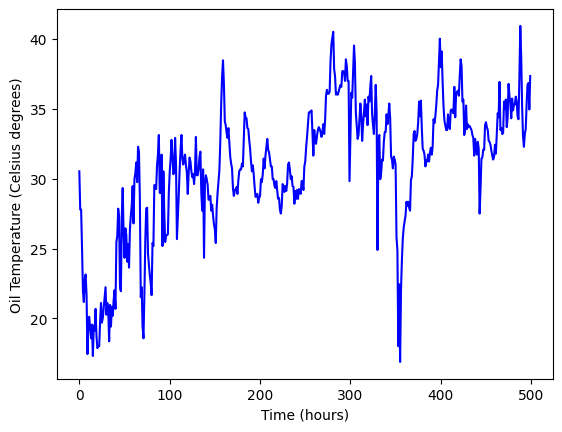

In [5]:
plt.plot(series[:500], color='blue')
plt.xlabel("Time (hours)")
plt.ylabel("Oil Temperature (Celsius degrees)")
plt.show()

**Question 2.** Implement a PyTorch `DataLoader` that reads the CSV file at initialization time, allows you to specify the past window length and forecast horizon, and provides batches of `(past, horizon)` pairs for the univariate forecasting problem.

In [6]:
class ForecastingDataset(torch.utils.data.Dataset):
    """Windowed univariate forecasting dataset."""

    def __init__(self,
                 csv_path: str,
                 window: int,
                 horizon: int,
                 target_col: int = -1):
        super().__init__()
        raw = numpy.loadtxt(csv_path, delimiter=",", skiprows=1, usecols=target_col)
        series = raw.astype(numpy.float32)
        self.window = window
        self.horizon = horizon
        self.series = series
        self.max_start = len(series) - window - horizon + 1
        if self.max_start < 1:
            raise ValueError("Window + horizon larger than available series length")

    def __len__(self):
        return self.max_start

    def __getitem__(self, idx: int):
        start = idx
        past = self.series[start : start + self.window]
        future = self.series[start + self.window : start + self.window + self.horizon]
        past = torch.from_numpy(past)  # shape: (window,)
        future = torch.from_numpy(future)  # shape: (horizon,)
        return past, future


def build_dataloader(csv_path: str,
                     window: int,
                     horizon: int,
                     batch_size: int = 32,
                     shuffle: bool = True):
    """Create a DataLoader emitting `(past, horizon)` batches."""
    dataset = ForecastingDataset(csv_path=csv_path,
                                 window=window,
                                 horizon=horizon)
    return torch.utils.data.DataLoader(dataset,
                                       batch_size=batch_size,
                                       shuffle=shuffle,
                                       drop_last=False)

**Question 3.** Improve your `build_dataloader` function above to build both a training data loader and a validation data loader. What would be appropriate choices for a clean separation between training and validation datasets?

In [7]:
class ForecastingDataset(torch.utils.data.Dataset):
    """Windowed univariate forecasting dataset."""

    def __init__(self,
                 csv_path: str,
                 window: int,
                 horizon: int,
                 target_col: int = -1,
                 start: int = 0,
                 end: int = None):
        super().__init__()
        raw = numpy.loadtxt(csv_path, delimiter=",", skiprows=1, usecols=target_col)
        series = raw.astype(numpy.float32)
        if end is None:
            series = series[start:]
        else:
            series = series[start:end]
        self.window = window
        self.horizon = horizon
        self.series = series
        self.max_start = len(series) - window - horizon + 1
        if self.max_start < 1:
            raise ValueError("Window + horizon larger than available series length")

    def __len__(self):
        return self.max_start

    def __getitem__(self, idx: int):
        start = idx
        past = self.series[start : start + self.window]
        future = self.series[start + self.window : start + self.window + self.horizon]
        past = torch.from_numpy(past)  # shape: (window,)
        future = torch.from_numpy(future)  # shape: (horizon,)
        return past, future


def build_dataloader(csv_path: str,
                     window: int,
                     horizon: int,
                     batch_size: int = 32,
                     shuffle: bool = True):
    """Create a DataLoader emitting `(past, horizon)` batches."""
    dataset = ForecastingDataset(csv_path=csv_path,
                                 window=window,
                                 horizon=horizon)
    train_dataset = ForecastingDataset(csv_path=csv_path,
                                       window=window,
                                       horizon=horizon,
                                       end=len(dataset) // 5)
    train_dl = torch.utils.data.DataLoader(train_dataset,
                                           batch_size=batch_size,
                                           shuffle=shuffle,
                                           drop_last=False)
    valid_dataset = ForecastingDataset(csv_path=csv_path,
                                       window=window,
                                       horizon=horizon,
                                       start=len(dataset) // 5)
    valid_dl = torch.utils.data.DataLoader(valid_dataset,
                                           batch_size=batch_size,
                                           shuffle=shuffle,
                                           drop_last=False)
    return train_dl, valid_dl

## Part 2: First models

In this part, you will build your first few forecasting models, train them, and
experiment with classical detrending techniques used in time series analysis.

**Question 4.** Implement a simple autoregressive (AR) model in `torch`.

The model should:
- take a past window of shape `(batch, window)`
- output a forecast of shape `(batch, horizon)`
- be linear in the inputs

In [8]:
class ARModel(torch.nn.Module):
    """Simple autoregressive model."""

    def __init__(self, window: int, horizon: int):
        super().__init__()
        self.linear = torch.nn.Linear(window, horizon)

    def forward(self, past):
      ## past - (batch, window)
      ## output - (batch, horizon)

      return self.linear(past)

**Question 5.** Train the AR model using mean squared error (MSE) and evaluate
it on the validation set.

Implement:
- a training loop
- a validation loop
- reporting of train and validation losses

In [10]:
def train_epoch(model, dataloader, optimizer, criterion):
  model.train()
  total_loss= 0

  for past, future in dataloader:
    optimizer.zero_grad()
    pred = model(past)
    loss = criterion(pred, future)
    loss.backward()
    optimizer.step()
    total_loss += loss.item() * past.size(0)

  return total_loss / len(dataloader.dataset)

@torch.no_grad()
def eval_epoch(model, dataloader, criterion):
  model.eval()
  total_loss = 0

  for past, future in dataloader:
    pred = model(past)
    loss = criterion(pred, future)
    total_loss += loss.item() * past.size(0)

  return total_loss / len(dataloader.dataset)

def train_and_valid_loop(model, train_dl, valid_dl, optimizer, criterion, n_epochs):
    logs = {"train_loss": [], "valid_loss": []}
    print(model.__class__.__name__)
    for epoch in range(n_epochs):
        train_loss = train_epoch(model, train_dl, optimizer, criterion)
        logs["train_loss"].append(train_loss)
        valid_loss = eval_epoch(model, valid_dl, criterion)
        logs["valid_loss"].append(valid_loss)
        print(f"Epoch {epoch:02d} | train={train_loss:.4f} | valid={valid_loss:.4f}")
    return logs

# Example
window = 96
horizon = 24
n_epochs = 50

train_dl, valid_dl = build_dataloader(
    csv_path="/content/ETTh1.csv",
    window=window,
    horizon=horizon,
    batch_size=64
)

ar_model = ARModel(window, horizon)
optimizer = torch.optim.Adam(ar_model.parameters(), lr=1e-3)
criterion = torch.nn.MSELoss()
logs_AR = train_and_valid_loop(ar_model, train_dl, valid_dl, optimizer, criterion, n_epochs)

ARModel
Epoch 00 | train=106.1173 | valid=10.9306
Epoch 01 | train=14.6751 | valid=9.9655
Epoch 02 | train=13.4242 | valid=9.3318
Epoch 03 | train=12.5985 | valid=8.7627
Epoch 04 | train=11.7833 | valid=8.2992
Epoch 05 | train=11.1648 | valid=7.9313
Epoch 06 | train=10.6431 | valid=7.6294
Epoch 07 | train=10.2256 | valid=7.3677
Epoch 08 | train=9.8578 | valid=7.1507
Epoch 09 | train=9.5098 | valid=6.9708
Epoch 10 | train=9.2795 | valid=6.7942
Epoch 11 | train=9.0223 | valid=6.6490
Epoch 12 | train=8.8220 | valid=6.5118
Epoch 13 | train=8.6031 | valid=6.4177
Epoch 14 | train=8.4657 | valid=6.3057
Epoch 15 | train=8.3217 | valid=6.2412
Epoch 16 | train=8.2351 | valid=6.1367
Epoch 17 | train=8.0845 | valid=6.0600
Epoch 18 | train=8.0317 | valid=5.9920
Epoch 19 | train=7.8372 | valid=5.9633
Epoch 20 | train=7.7707 | valid=5.8785
Epoch 21 | train=7.8059 | valid=5.8306
Epoch 22 | train=7.6424 | valid=5.7715
Epoch 23 | train=7.4963 | valid=5.7440
Epoch 24 | train=7.4927 | valid=5.8542
Epoch 2

**Question 6.** Add input/output standardization layers.

In [11]:
class StandardScaler(torch.nn.Module):
    """Fixed standardization layer."""

    def __init__(self, mean, std):
        super().__init__()
        self.register_buffer("mean", mean)
        self.register_buffer("std", std)

    def forward(self, x):
        return (x - self.mean) / (self.std + 1e-6)

    def inverse(self, x):
        return x * (self.std + 1e-6) + self.mean

def compute_scaler(dataloader):
    values = []
    for past, future in dataloader:
        values.append(past[:, :1])
    values = torch.cat(values, dim=0)
    mean = values.mean()
    std = values.std()
    return mean, std


class ScaledARModel(ARModel):
    def __init__(self, window, horizon, mean, std):
        super().__init__(window, horizon)
        self.scaler = StandardScaler(mean, std)

    def forward(self, past):
        past_scaled = self.scaler(past)
        pred_scaled = self.linear(past_scaled)
        return self.scaler.inverse(pred_scaled)

# Compute scaler from training data only
mean, std = compute_scaler(train_dl)
scaled_ar_model = ScaledARModel(window, horizon, mean, std)
optimizer = torch.optim.Adam(scaled_ar_model.parameters(), lr=1e-3)
criterion = torch.nn.MSELoss()
logs_scaledAR = train_and_valid_loop(scaled_ar_model, train_dl, valid_dl, optimizer, criterion, n_epochs)

ScaledARModel
Epoch 00 | train=23.8331 | valid=9.2960
Epoch 01 | train=11.1097 | valid=7.6288
Epoch 02 | train=9.5946 | valid=6.9038
Epoch 03 | train=8.7092 | valid=6.4399
Epoch 04 | train=8.1608 | valid=6.1691
Epoch 05 | train=7.8072 | valid=5.9375
Epoch 06 | train=7.5007 | valid=5.8199
Epoch 07 | train=7.2842 | valid=5.7745
Epoch 08 | train=7.1773 | valid=5.7548
Epoch 09 | train=7.0368 | valid=5.4659
Epoch 10 | train=6.9807 | valid=5.9821
Epoch 11 | train=6.8942 | valid=5.4208
Epoch 12 | train=6.7849 | valid=5.5262
Epoch 13 | train=6.7128 | valid=5.3628
Epoch 14 | train=6.6583 | valid=5.3104
Epoch 15 | train=6.6233 | valid=5.4594
Epoch 16 | train=6.6004 | valid=5.2818
Epoch 17 | train=6.5820 | valid=5.3301
Epoch 18 | train=6.5226 | valid=5.3725
Epoch 19 | train=6.4929 | valid=5.6439
Epoch 20 | train=6.4852 | valid=5.1876
Epoch 21 | train=6.4445 | valid=5.3033
Epoch 22 | train=6.4211 | valid=5.1747
Epoch 23 | train=6.4170 | valid=5.2203
Epoch 24 | train=6.3739 | valid=5.0869
Epoch 25 

**Question 7.** Implement a differencing layer that removes local trends:

  $x_t' = x_t - x_{t-1}$

Then implement the inverse operation (integration) to recover forecasts
back to the original scale.

Experiment with how differencing affects convergence and final error, and
compare forecasts qualitatively.

In [13]:
class Differencing(torch.nn.Module):

  def forward(self, x):
    return x[:, 1:] - x[:, :-1]

class Integration(torch.nn.Module):
  def forward(self, last_value, diffs):
    return last_value + torch.cumsum(diffs, dim=1)

class DifferencedScaledARModel(torch.nn.Module):
  def __init__(self, window, horizon, mean, std):
    super().__init__()
    self.scaler = StandardScaler(mean, std)
    self.diff = Differencing()
    self.ar= ARModel(window-1, horizon)
    self.integration = Integration()

  def forward(self, past):
    past_scaled = self.scaler(past)
    last_value = past_scaled[:, -1:].detach()
    past_diff = self.diff(past_scaled)
    pred_diff = self.ar(past_diff)
    pred_scaled = self.integration(last_value, pred_diff)
    return self.scaler.inverse(pred_scaled)

# Compute scaler from training data only
mean, std = compute_scaler(train_dl)
diff_scaled_ar_model = DifferencedScaledARModel(window, horizon, mean, std)
optimizer = torch.optim.Adam(diff_scaled_ar_model.parameters(), lr=1e-3)
criterion = torch.nn.MSELoss()

logs_DifferencedScaledAR = train_and_valid_loop(diff_scaled_ar_model, train_dl, valid_dl, optimizer, criterion, n_epochs)

DifferencedScaledARModel
Epoch 00 | train=9.5871 | valid=5.7239
Epoch 01 | train=7.3459 | valid=5.2906
Epoch 02 | train=6.9772 | valid=5.1449
Epoch 03 | train=6.7687 | valid=5.0645
Epoch 04 | train=6.6624 | valid=5.0274
Epoch 05 | train=6.5539 | valid=5.0378
Epoch 06 | train=6.6176 | valid=4.9951
Epoch 07 | train=6.5273 | valid=4.9475
Epoch 08 | train=6.4717 | valid=4.9125
Epoch 09 | train=6.4770 | valid=4.9013
Epoch 10 | train=6.4808 | valid=4.9004
Epoch 11 | train=6.4015 | valid=4.8847
Epoch 12 | train=6.4507 | valid=4.8962
Epoch 13 | train=6.4269 | valid=4.8856
Epoch 14 | train=6.4015 | valid=4.9285
Epoch 15 | train=6.3465 | valid=4.8788
Epoch 16 | train=6.3744 | valid=4.8785
Epoch 17 | train=6.3596 | valid=4.8774
Epoch 18 | train=6.3673 | valid=4.8688
Epoch 19 | train=6.3570 | valid=4.8768
Epoch 20 | train=6.3648 | valid=4.8622
Epoch 21 | train=6.3691 | valid=4.8668
Epoch 22 | train=6.3641 | valid=4.8421
Epoch 23 | train=6.3419 | valid=4.8632
Epoch 24 | train=6.3087 | valid=4.8335


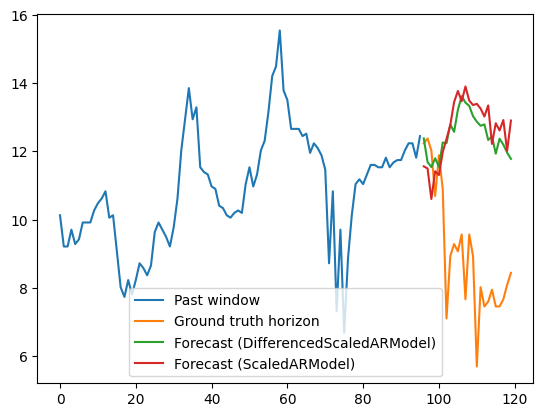

In [14]:
def viz_forecast(list_models: list, dataloader: torch.utils.data.DataLoader, ts_id: int = 0):
    past_val, future_val = next(iter(dataloader))
    plt.plot(numpy.arange(past_val.shape[1]),
            past_val[ts_id],
            label="Past window"
    )
    plt.plot(past_val.shape[1] + numpy.arange(future_val.shape[1]),
            future_val[ts_id],
            label="Ground truth horizon"
    )
    for model in list_models:
        pred_val = model(past_val).detach().numpy()
        plt.plot(past_val.shape[1] + numpy.arange(pred_val.shape[1]),
                pred_val[ts_id],
                label=f"Forecast ({model.__class__.__name__})"
        )
    plt.legend()
    plt.show()

viz_forecast([diff_scaled_ar_model, scaled_ar_model], valid_dl)

**Question 8.** Replace the linear layer in your best-performing AR model with MLPs.

Compare:
- convergence speed
- validation error

In [15]:
class MLP(torch.nn.Module):
    def __init__(self, in_dim, out_dim, hidden=128):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(in_dim, hidden),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden, hidden),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden, out_dim),
        )

    def forward(self, x):
        return self.net(x)

class DifferencedScaledDeepARModel(DifferencedScaledARModel):
    def __init__(self, window, horizon, mean, std):
        super().__init__(window, horizon, mean, std)
        self.ar = MLP(window - 1, horizon)

# Compute scaler from training data only
mean, std = compute_scaler(train_dl)
diff_scaled_deep_ar_model = DifferencedScaledDeepARModel(window, horizon, mean, std)
optimizer = torch.optim.Adam(diff_scaled_deep_ar_model.parameters(), lr=1e-3)
criterion = torch.nn.MSELoss()

logs_DifferencedScaledDeepAR = train_and_valid_loop(diff_scaled_deep_ar_model, train_dl, valid_dl, optimizer, criterion, n_epochs)

DifferencedScaledDeepARModel
Epoch 00 | train=8.2844 | valid=5.2766
Epoch 01 | train=6.5706 | valid=5.0608
Epoch 02 | train=6.0352 | valid=4.9028
Epoch 03 | train=5.5320 | valid=4.9352
Epoch 04 | train=5.1814 | valid=5.0531
Epoch 05 | train=4.7325 | valid=4.9775
Epoch 06 | train=4.4640 | valid=5.2252
Epoch 07 | train=4.1360 | valid=5.1999
Epoch 08 | train=3.9280 | valid=5.2306
Epoch 09 | train=3.6799 | valid=5.5028
Epoch 10 | train=3.4655 | valid=5.4891
Epoch 11 | train=3.2448 | valid=5.6121
Epoch 12 | train=3.0860 | valid=5.8817
Epoch 13 | train=3.0103 | valid=5.9608
Epoch 14 | train=2.8659 | valid=5.9692
Epoch 15 | train=2.7615 | valid=6.1561
Epoch 16 | train=2.5777 | valid=6.0713
Epoch 17 | train=2.6141 | valid=6.2057
Epoch 18 | train=2.5154 | valid=6.4672
Epoch 19 | train=2.3608 | valid=6.4565
Epoch 20 | train=2.2662 | valid=6.3646
Epoch 21 | train=2.1536 | valid=6.5765
Epoch 22 | train=2.1091 | valid=6.5254
Epoch 23 | train=2.0346 | valid=6.6324
Epoch 24 | train=1.9792 | valid=6.7

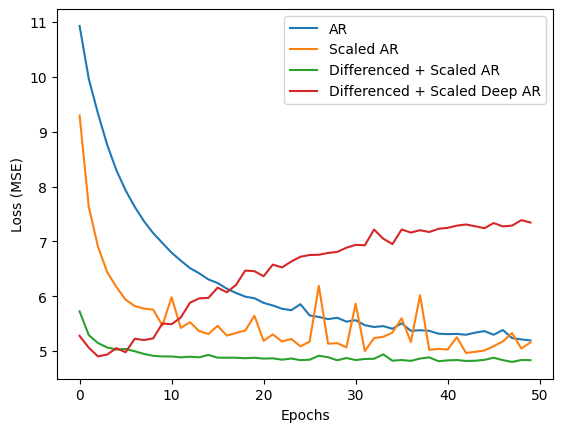

In [16]:
plt.plot(logs_AR["valid_loss"], label="AR")
plt.plot(logs_scaledAR["valid_loss"], label="Scaled AR")
plt.plot(logs_DifferencedScaledAR["valid_loss"], label="Differenced + Scaled AR")
plt.plot(logs_DifferencedScaledDeepAR["valid_loss"], label="Differenced + Scaled Deep AR")
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.show()

**Bonus question.** Given what you know about this time series, do you expect seasonality?
Implement an additional layer for your scaled differenced AR model that performs seasonal differencing using a lag equal to the expected period $\Delta_t$:

$x_t' = x_t - x_{t-\Delta_t}$

Does it help improve overall performance?

In [17]:
## Already given

class SeasonalDifferencing(torch.nn.Module):
    """Seasonal differencing: x_t' = x_t - x_{t-lag}"""

    def __init__(self, lag: int):
        super().__init__()
        self.lag = lag

    def forward(self, x):
        return x[:, self.lag:] - x[:, :-self.lag]


class SeasonalIntegration(torch.nn.Module):
    """Inverse of seasonal differencing: x_t = x_{t-lag} + x_t'"""

    def __init__(self, lag: int):
        super().__init__()
        self.lag = lag

    def forward(self, last_season_values, diff_preds):
        horizon = diff_preds.shape[1]
        preds = []
        extended_history = last_season_values  # (batch, lag)

        for t in range(horizon):
            # The base value is from 'lag' steps ago
            if t < self.lag:
                # Use value from last_season_values
                base_value = extended_history[:, t:t+1]
            else:
                # Use previously predicted value
                base_value = preds[t - self.lag]

            # Compute prediction: x_t = x_{t-lag} + diff
            new_pred = base_value + diff_preds[:, t:t+1]
            preds.append(new_pred)

        return torch.cat(preds, dim=1)


class SeasonalDifferencedScaledARModel(torch.nn.Module):
    """AR model with seasonal differencing and scaling"""

    def __init__(self, window: int, horizon: int, mean: float, std: float, lag: int = 24):
        super().__init__()
        assert(lag < window)
        self.scaler = StandardScaler(mean, std)
        self.seasonal_diff = SeasonalDifferencing(lag=lag)
        self.ar = ARModel(window - lag, horizon)  # Window size reduced by lag
        self.seasonal_integrate = SeasonalIntegration(lag=lag)
        self.lag = lag

    def forward(self, past):
        scaled_past = self.scaler(past)
        last_season_values = scaled_past[:, -self.lag:].detach() # Save for later (integration)
        seasonally_differenced = self.seasonal_diff(scaled_past)
        pred_diffs = self.ar(seasonally_differenced)
        scaled_preds = self.seasonal_integrate(last_season_values, pred_diffs)
        return self.scaler.inverse(scaled_preds)

# Assuming daily seasonality for hourly data (lag=24 hours)
mean, std = compute_scaler(train_dl)
seasonal_diff_scaled_ar_model = SeasonalDifferencedScaledARModel(
    window=window,
    horizon=horizon,
    mean=mean,
    std=std,
    lag=24  # Daily seasonality for hourly data
)
optimizer = torch.optim.Adam(seasonal_diff_scaled_ar_model.parameters(), lr=1e-3)
criterion = torch.nn.MSELoss()
logs_SeasonalDifferencedScaledAR = train_and_valid_loop(
    seasonal_diff_scaled_ar_model, train_dl, valid_dl, optimizer, criterion, n_epochs
)

SeasonalDifferencedScaledARModel
Epoch 00 | train=10.7640 | valid=7.1745
Epoch 01 | train=8.4888 | valid=6.4063
Epoch 02 | train=7.8141 | valid=6.0696
Epoch 03 | train=7.4641 | valid=5.8375
Epoch 04 | train=7.2306 | valid=5.6873
Epoch 05 | train=7.0807 | valid=5.6018
Epoch 06 | train=6.9670 | valid=5.5095
Epoch 07 | train=6.8777 | valid=5.4582
Epoch 08 | train=6.8051 | valid=5.3957
Epoch 09 | train=6.7454 | valid=5.3418
Epoch 10 | train=6.6985 | valid=5.3275
Epoch 11 | train=6.6557 | valid=5.2993
Epoch 12 | train=6.6077 | valid=5.2948
Epoch 13 | train=6.5915 | valid=5.2325
Epoch 14 | train=6.5531 | valid=5.2088
Epoch 15 | train=6.5265 | valid=5.2112
Epoch 16 | train=6.5014 | valid=5.1929
Epoch 17 | train=6.4798 | valid=5.1576
Epoch 18 | train=6.4580 | valid=5.1283
Epoch 19 | train=6.4476 | valid=5.1309
Epoch 20 | train=6.4182 | valid=5.1317
Epoch 21 | train=6.4166 | valid=5.1103
Epoch 22 | train=6.4120 | valid=5.1053
Epoch 23 | train=6.3911 | valid=5.0931
Epoch 24 | train=6.3780 | vali